In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("e.orders.csv")
details = pd.read_csv("e.details.csv")

In [4]:
print(orders.head())

print(details.head())

  Order ID  Order Date CustomerName        State    City
0  B-25923  12/27/2018        Gopal  Maharashtra  Mumbai
1  B-25858  11/13/2018       Uudhav  Maharashtra  Mumbai
2  B-26099   3/30/2018       Bhishm  Maharashtra  Mumbai
3  B-25823  10/18/2018        Rohan  Maharashtra  Mumbai
4  B-25902  10/12/2018     Ishpreet  Maharashtra  Mumbai
  Order ID  Amount  Profit  Quantity  Category Sub-Category PaymentMode  AOV
0  B-25696     275    -275         4  Clothing        Saree         COD   69
1  B-25675     929     -93         9  Clothing        Saree         COD  103
2  B-25650     512    -225         5  Clothing        Saree         COD  102
3  B-25787     556    -209         7  Clothing        Saree         COD   79
4  B-25691     714      56         4  Clothing        Saree         COD  179


In [5]:
orders.info()

details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
 7   AOV           1500 non-null   int64 
dtypes: int64(4), object(4)
memory 

In [6]:
print(orders.shape)

print(details.shape)

(500, 5)
(1500, 8)


In [7]:
print(orders.columns)

print(details.columns)

Index(['Order ID', 'Order Date', 'CustomerName', 'State', 'City'], dtype='object')
Index(['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category',
       'PaymentMode', 'AOV'],
      dtype='object')


In [8]:
orders.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

In [9]:
details.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
AOV             0
dtype: int64

In [10]:
orders = orders.dropna()

details = details.dropna()

In [11]:
orders.duplicated().sum()

0

In [12]:
details.duplicated().sum()

0

In [13]:
orders.drop_duplicates(inplace=True)

details.drop_duplicates(inplace=True)

In [14]:
orders.dtypes

Order ID        object
Order Date      object
CustomerName    object
State           object
City            object
dtype: object

In [15]:
details.dtypes

Order ID        object
Amount           int64
Profit           int64
Quantity         int64
Category        object
Sub-Category    object
PaymentMode     object
AOV              int64
dtype: object

In [16]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"])

In [17]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      500 non-null    object        
 1   Order Date    500 non-null    datetime64[ns]
 2   CustomerName  500 non-null    object        
 3   State         500 non-null    object        
 4   City          500 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 19.7+ KB


In [18]:
orders["Year"] = orders["Order Date"].dt.year

In [19]:
orders["Month"] = orders["Order Date"].dt.month

In [20]:
orders["Month_Name"] = orders["Order Date"].dt.month_name()

In [21]:
orders["Quarter"] = orders["Order Date"].dt.quarter

In [22]:
orders["Day"] = orders["Order Date"].dt.day

In [23]:
orders["Weekday"] = orders["Order Date"].dt.day_name()

In [24]:
df = pd.merge(
    orders,
    details,
    on="Order ID",
    how="inner"
)

In [25]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Year,Month,Month_Name,Quarter,Day,Weekday,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,AOV
0,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai,2018,12,December,4,27,Thursday,226,58,3,Electronics,Accessories,COD,75
1,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai,2018,12,December,4,27,Thursday,3873,-891,6,Electronics,Phones,Credit Card,646
2,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai,2018,12,December,4,27,Thursday,484,28,3,Electronics,Printers,Debit Card,161
3,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai,2018,12,December,4,27,Thursday,253,-11,1,Clothing,Trousers,Debit Card,253
4,B-25858,2018-11-13,Uudhav,Maharashtra,Mumbai,2018,11,November,4,13,Tuesday,245,30,2,Clothing,Saree,COD,123


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   object        
 1   Order Date    1500 non-null   datetime64[ns]
 2   CustomerName  1500 non-null   object        
 3   State         1500 non-null   object        
 4   City          1500 non-null   object        
 5   Year          1500 non-null   int32         
 6   Month         1500 non-null   int32         
 7   Month_Name    1500 non-null   object        
 8   Quarter       1500 non-null   int32         
 9   Day           1500 non-null   int32         
 10  Weekday       1500 non-null   object        
 11  Amount        1500 non-null   int64         
 12  Profit        1500 non-null   int64         
 13  Quantity      1500 non-null   int64         
 14  Category      1500 non-null   object        
 15  Sub-Category  1500 non-null   object  

In [27]:
df.shape

(1500, 18)

In [28]:
df.describe()

,Order Date,Year,Month,Quarter,Day,Amount,Profit,Quantity,AOV
count,1500,1500.0,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000
mean,2018-06-16 16:25:55.200000,2018.0,6.050667,2.375333,14.867333,291.847333,24.64200,3.743333,80.676000
min,2018-01-01 00:00:00,2018.0,1.000000,1.000000,1.000000,4.000000,-1981.00000,1.000000,2.000000
25%,2018-03-16 00:00:00,2018.0,3.000000,1.000000,7.000000,47.750000,-12.00000,2.000000,15.000000
50%,2018-06-18 00:00:00,2018.0,6.000000,2.000000,14.000000,122.000000,8.00000,3.000000,40.000000
75%,2018-09-16 00:00:00,2018.0,9.000000,3.000000,22.000000,326.250000,38.00000,5.000000,109.000000
max,2018-12-31 00:00:00,2018.0,12.000000,4.000000,31.000000,5729.000000,1864.00000,14.000000,873.000000
std,NaN,0.0,3.480447,1.145134,8.760645,461.924620,168.55881,2.184942,108.237455


In [29]:
df.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
Year            0
Month           0
Month_Name      0
Quarter         0
Day             0
Weekday         0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
AOV             0
dtype: int64

#Profit Percentage

In [30]:
df["Profit %"] = (df["Profit"] / df["Amount"]) * 100

#Revenue Per Quantity

In [31]:
df["Revenue per Qty"] = df["Amount"] / df["Quantity"]

#Loss orders

In [32]:
df["Loss"] = np.where(df["Profit"] < 0, "Yes", "No")

#High Value Orders

In [33]:
df["High Value"] = np.where(df["Amount"] > 1000, "Yes", "No")

#OrderSize

In [34]:
df["Order Size"] = pd.cut(
    df["Amount"],
    bins=[0,500,1000,5000,100000],
    labels=["Small","Medium","Large","Premium"]
)

In [35]:
df.rename(columns={
    "Order ID":"Order_ID",
    "Order Date":"Order_Date",
    "CustomerName":"Customer_Name"
}, inplace=True)

In [36]:
df.sort_values(
    by="Amount",
    ascending=False,
    inplace=True
)

In [37]:
df.reset_index(drop=True, inplace=True)

In [38]:
df.head(10)

,Order_ID,Order_Date,Customer_Name,State,City,Year,Month,Month_Name,Quarter,Day,...,Quantity,Category,Sub-Category,PaymentMode,AOV,Profit %,Revenue per Qty,Loss,High Value,Order Size
0,B-26055,2018-10-03,Harivansh,Uttar Pradesh,Mathura,2018,10,October,4,3,...,14,Furniture,Chairs,EMI,409,1.117123,409.214286,No,Yes,Premium
1,B-25993,2018-03-02,Madhav,Delhi,Delhi,2018,3,March,1,2,...,5,Furniture,Tables,EMI,873,6.990603,872.600000,No,Yes,Large
2,B-25973,2018-01-24,Madan Mohan,Uttar Pradesh,Mathura,2018,1,January,1,24,...,13,Electronics,Printers,COD,319,41.004588,318.538462,No,Yes,Large
3,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai,2018,12,December,4,27,...,6,Electronics,Phones,Credit Card,646,-23.005422,645.500000,Yes,Yes,Large
4,B-25757,2018-08-21,Vishakha,Madhya Pradesh,Indore,2018,8,August,3,21,...,7,Clothing,Trousers,EMI,450,-1.110758,450.142857,Yes,Yes,Large
5,B-25955,2018-01-16,Shiva,Maharashtra,Pune,2018,1,January,1,16,...,8,Furniture,Bookcases,EMI,366,4.988042,365.875000,No,Yes,Large
6,B-26093,2018-03-27,Sarita,Maharashtra,Pune,2018,3,March,1,27,...,8,Electronics,Printers,Credit Card,356,25.008781,355.875000,No,Yes,Large
7,B-25798,2018-01-10,Shishu,Andhra Pradesh,Hyderabad,2018,1,January,1,10,...,13,Furniture,Bookcases,EMI,218,-70.000000,217.692308,Yes,Yes,Large
8,B-25602,2018-01-04,Vrinda,Maharashtra,Pune,2018,1,January,1,4,...,4,Electronics,Phones,Credit Card,654,43.981658,654.250000,No,Yes,Large
9,B-25858,2018-11-13,Uudhav,Maharashtra,Mumbai,2018,11,November,4,13,...,11,Electronics,Electronic Games,EMI,223,27.065527,223.363636,No,Yes,Large


In [39]:
df.to_csv(
    "cleaned_ecommerce.csv",
    index=False
)

In [40]:
print(df.shape)

print(df.columns)

print(df.head())

(1500, 23)
Index(['Order_ID', 'Order_Date', 'Customer_Name', 'State', 'City', 'Year',
       'Month', 'Month_Name', 'Quarter', 'Day', 'Weekday', 'Amount', 'Profit',
       'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'AOV',
       'Profit %', 'Revenue per Qty', 'Loss', 'High Value', 'Order Size'],
      dtype='object')
  Order_ID Order_Date Customer_Name           State     City  Year  Month  \
0  B-26055 2018-10-03     Harivansh   Uttar Pradesh  Mathura  2018     10   
1  B-25993 2018-03-02        Madhav           Delhi    Delhi  2018      3   
2  B-25973 2018-01-24   Madan Mohan   Uttar Pradesh  Mathura  2018      1   
3  B-25923 2018-12-27         Gopal     Maharashtra   Mumbai  2018     12   
4  B-25757 2018-08-21      Vishakha  Madhya Pradesh   Indore  2018      8   

  Month_Name  Quarter  Day  ... Quantity     Category  Sub-Category  \
0    October        4    3  ...       14    Furniture        Chairs   
1      March        1    2  ...        5    Furniture        Tab

In [42]:
df = pd.read_csv("cleaned_ecommerce.csv")

In [43]:
print(df.head())

print(df.info())

print(df.describe())

  Order_ID  Order_Date Customer_Name           State     City  Year  Month  \
0  B-26055  2018-10-03     Harivansh   Uttar Pradesh  Mathura  2018     10   
1  B-25993  2018-03-02        Madhav           Delhi    Delhi  2018      3   
2  B-25973  2018-01-24   Madan Mohan   Uttar Pradesh  Mathura  2018      1   
3  B-25923  2018-12-27         Gopal     Maharashtra   Mumbai  2018     12   
4  B-25757  2018-08-21      Vishakha  Madhya Pradesh   Indore  2018      8   

  Month_Name  Quarter  Day  ... Quantity     Category  Sub-Category  \
0    October        4    3  ...       14    Furniture        Chairs   
1      March        1    2  ...        5    Furniture        Tables   
2    January        1   24  ...       13  Electronics      Printers   
3   December        4   27  ...        6  Electronics        Phones   
4     August        3   21  ...        7     Clothing      Trousers   

   PaymentMode  AOV   Profit % Revenue per Qty  Loss  High Value  Order Size  
0          EMI  409   1.1

In [44]:
total_sales = df["Amount"].sum()

print("Total Sales :", total_sales)

Total Sales : 437771


In [45]:
total_profit = df["Profit"].sum()

print("Total Profit :", total_profit)

Total Profit : 36963


In [46]:
average_order = df["Amount"].mean()

print("Average Order Value :", average_order)

Average Order Value : 291.8473333333333


In [47]:
print("Total Orders :", df["Order_ID"].nunique())

Total Orders : 500


In [48]:
print("Total Customers :", df["Customer_Name"].nunique())

Total Customers : 336


In [49]:
print(df["Quantity"].sum())

5615


In [50]:
category_sales = df.groupby("Category")["Amount"].sum()

print(category_sales)

Category
Clothing       144323
Electronics    166267
Furniture      127181
Name: Amount, dtype: int64


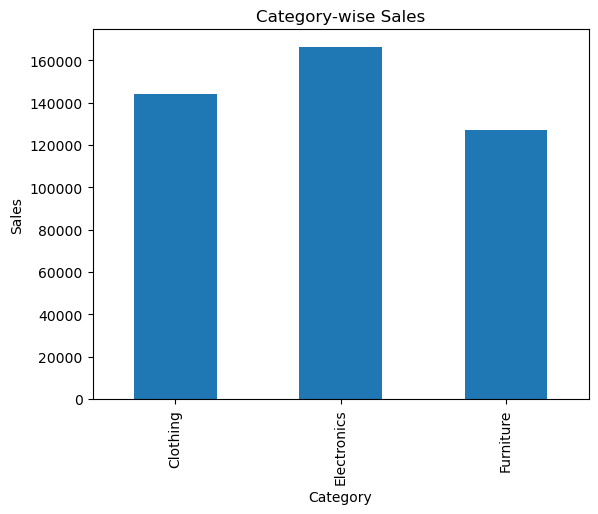

In [51]:
category_sales.plot(kind="bar")

plt.title("Category-wise Sales")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

In [52]:
category_profit = df.groupby("Category")["Profit"].sum()

print(category_profit)

Category
Clothing       13325
Electronics    13162
Furniture      10476
Name: Profit, dtype: int64


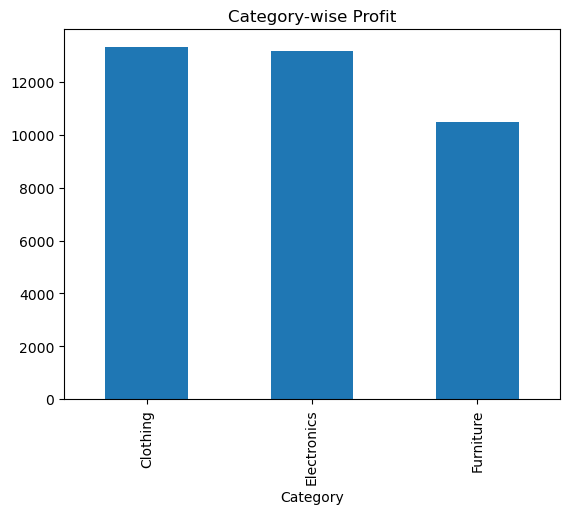

In [53]:
category_profit.plot(kind="bar")

plt.title("Category-wise Profit")

plt.show()

In [54]:
state_sales = df.groupby("State")["Amount"].sum().sort_values(ascending=False)

print(state_sales)

State
Maharashtra          102498
Madhya Pradesh        87463
Uttar Pradesh         38362
Delhi                 22957
Rajasthan             22334
Gujarat               21371
Punjab                16786
West Bengal           14328
Kerala                13871
Bihar                 13417
Andhra Pradesh        13256
Karnataka             12520
Nagaland              11993
Jammu and Kashmir     10829
Haryana                8863
Himachal Pradesh       8666
Goa                    6705
Tamil Nadu             6276
Sikkim                 5276
Name: Amount, dtype: int64


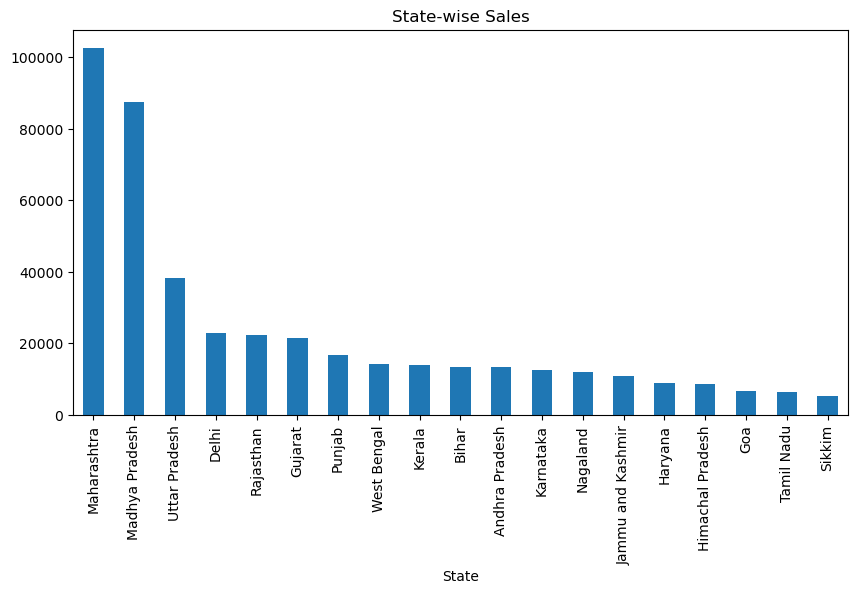

In [55]:
state_sales.plot(kind="bar", figsize=(10,5))

plt.title("State-wise Sales")

plt.show()

In [56]:
top_customers = df.groupby("Customer_Name")["Amount"].sum()

top_customers = top_customers.sort_values(ascending=False).head(10)

print(top_customers)

Customer_Name
Harivansh      9902
Madhav         9365
Madan Mohan    7766
Shiva          6339
Vishakha       6120
Vrinda         5820
Lalita         5809
Priyanka       5762
Shruti         5750
Abhijeet       5691
Name: Amount, dtype: int64


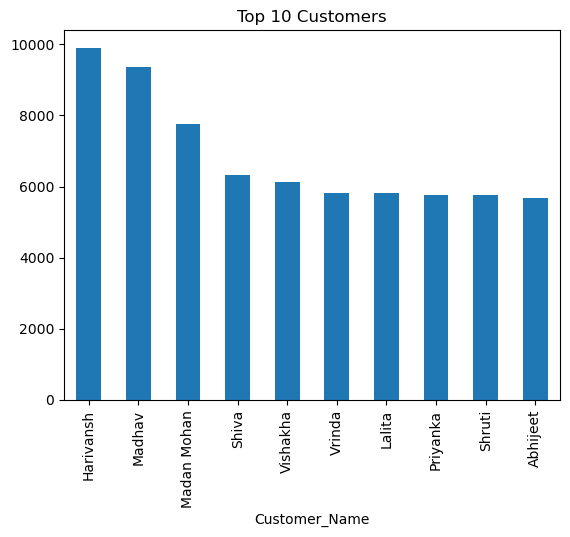

In [57]:
top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.show()

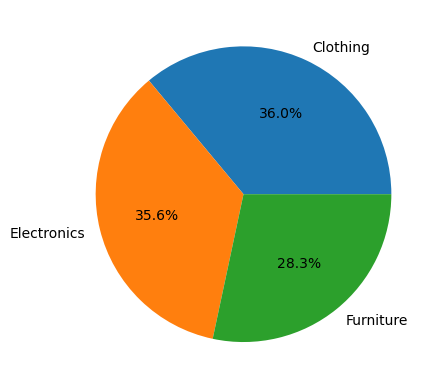

In [58]:
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(kind="pie",
                     autopct="%1.1f%%")

plt.ylabel("")

plt.show()

In [59]:
monthly_sales = df.groupby("Month_Name")["Amount"].sum()

print(monthly_sales)

Month_Name
April        38800
August       52509
December     24151
February     22638
January      68955
July         21024
June         21211
March        47491
May          24943
November     41296
October      48305
September    26448
Name: Amount, dtype: int64


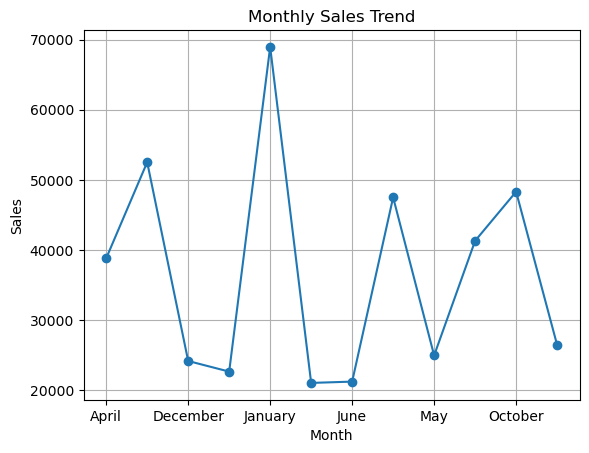

In [60]:
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

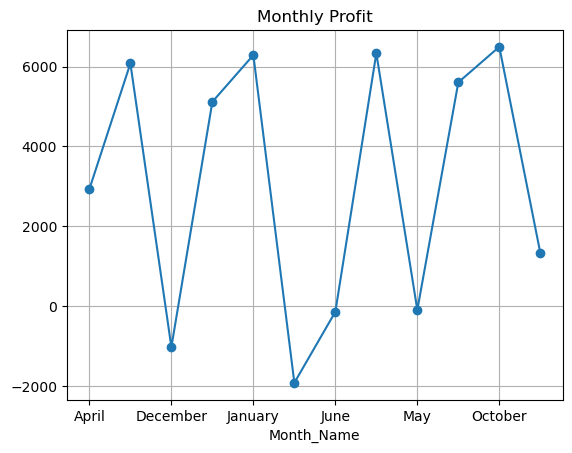

In [61]:
monthly_profit = df.groupby("Month_Name")["Profit"].sum()

monthly_profit.plot(marker="o")

plt.title("Monthly Profit")

plt.grid(True)

plt.show()

In [62]:
payment = df.groupby("PaymentMode")["Amount"].sum()

print(payment)

PaymentMode
COD            155181
Credit Card     86932
Debit Card      49136
EMI             77881
UPI             68641
Name: Amount, dtype: int64


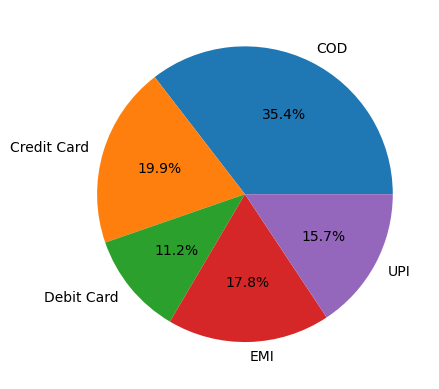

In [63]:
payment.plot(kind="pie",
             autopct="%1.1f%%")

plt.ylabel("")

plt.show()

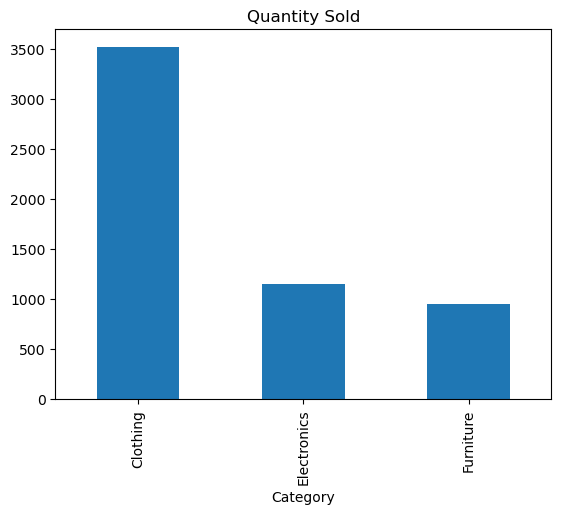

In [64]:
quantity = df.groupby("Category")["Quantity"].sum()

quantity.plot(kind="bar")

plt.title("Quantity Sold")

plt.show()

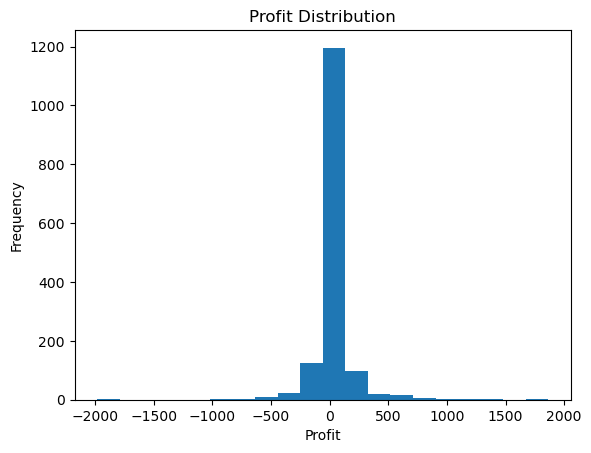

In [65]:
plt.hist(df["Profit"], bins=20)

plt.title("Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

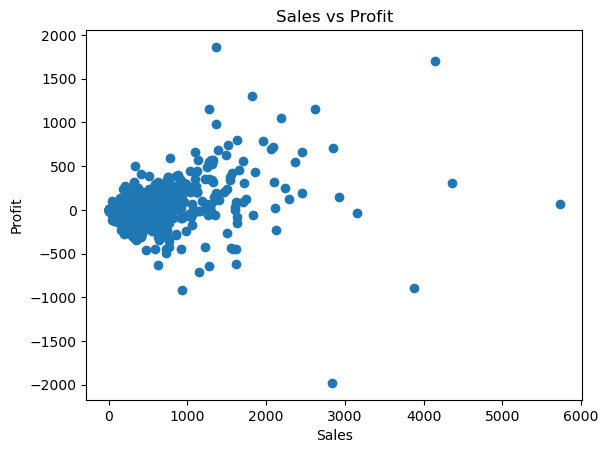

In [66]:
plt.scatter(df["Amount"],
            df["Profit"])

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.title("Sales vs Profit")

plt.show()

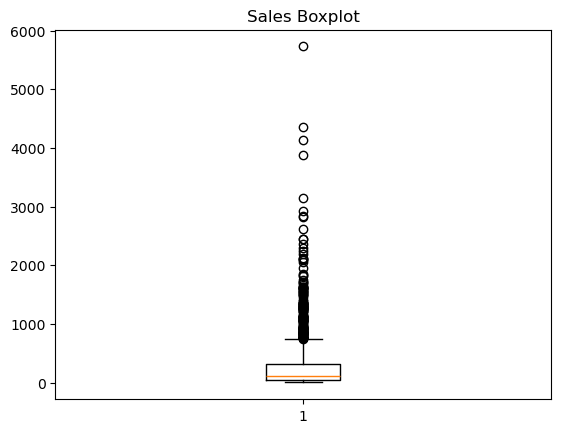

In [67]:
plt.boxplot(df["Amount"])

plt.title("Sales Boxplot")

plt.show()

In [68]:
profit_state = df.groupby("State")["Profit"].sum()

profit_state = profit_state.sort_values(ascending=False)

print(profit_state.head())

State
Madhya Pradesh    7382
Maharashtra       6963
Uttar Pradesh     3358
Gujarat           3001
Tamil Nadu        2602
Name: Profit, dtype: int64


In [69]:
top_products = df.groupby("Sub-Category")["Amount"].sum()

top_products = top_products.sort_values(ascending=False)

print(top_products.head(10))

Sub-Category
Printers            59252
Saree               59094
Bookcases           56861
Phones              46119
Electronic Games    39168
Chairs              34222
Trousers            30039
Tables              22614
Accessories         21728
Stole               18546
Name: Amount, dtype: int64


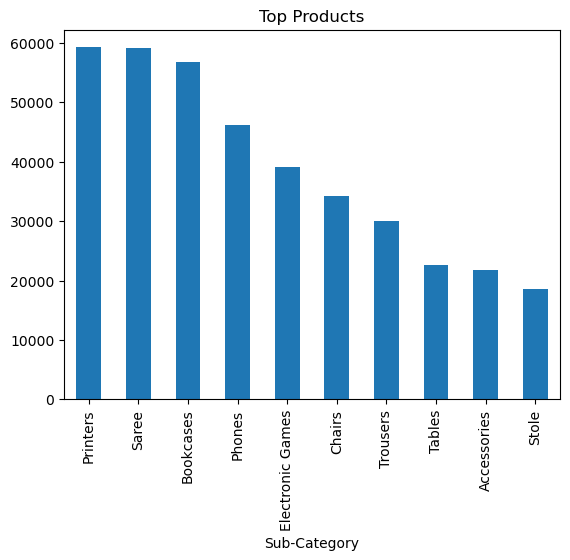

In [70]:
top_products.head(10).plot(kind="bar")

plt.title("Top Products")

plt.show()

In [71]:
loss = df.groupby("Category")["Profit"].sum()

loss = loss.sort_values()

print(loss)

Category
Furniture      10476
Electronics    13162
Clothing       13325
Name: Profit, dtype: int64


In [72]:
profit_margin = (df["Profit"].sum() / df["Amount"].sum()) * 100

print("Profit Margin :", profit_margin)

Profit Margin : 8.443455596647562


In [73]:
summary = pd.DataFrame({

    "Total Sales":[df["Amount"].sum()],

    "Total Profit":[df["Profit"].sum()],

    "Average Sales":[df["Amount"].mean()],

    "Total Orders":[df["Order_ID"].nunique()]

})

summary.to_csv("summary.csv",index=False)

In [74]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [75]:
pip show mysql-connector-python

Name: mysql-connector-python
Version: 9.7.0
Summary: A self-contained Python driver for communicating with MySQL servers, using an API that is compliant with the Python Database API Specification v2.0 (PEP 249).
Home-page: https://dev.mysql.com/doc/connector-python/en/
Author: Oracle and/or its affiliates
Author-email: 
License: GNU GPLv2 (with FOSS License Exception)
Location: c:\Users\HP\anaconda4\Lib\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [76]:
import mysql.connector
import pandas as pd

In [77]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Praveen@2102",
    database="ecommerce"
)

print("Connected Successfully")

Connected Successfully


In [78]:
cursor = conn.cursor()

In [79]:
cursor.execute("USE ecommerce")

In [80]:
create_table = """
CREATE TABLE IF NOT EXISTS orders (

Order_ID VARCHAR(20),
Order_Date DATE,
Customer_Name VARCHAR(100),
State VARCHAR(50),
City VARCHAR(50),

Amount FLOAT,
Profit FLOAT,
Quantity INT,

Category VARCHAR(50),
Sub_Category VARCHAR(50),
PaymentMode VARCHAR(50),

AOV FLOAT,

Year INT,
Month INT,
Month_Name VARCHAR(20),
Quarter INT,
Day INT,
Weekday VARCHAR(20),

Profit_Percentage FLOAT,
Revenue_Per_Qty FLOAT,

Loss VARCHAR(10),
High_Value VARCHAR(10),
Order_Size VARCHAR(20)

)
"""

cursor.execute(create_table)

conn.commit()

In [81]:
import pandas as pd

df = pd.read_csv("cleaned_ecommerce.csv")

In [86]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'State', 'City', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Weekday', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'AOV', 'Profit %', 'Revenue per Qty', 'Loss', 'High Value', 'Order Size']


In [87]:
cursor.execute("DESCRIBE orders")

for row in cursor.fetchall():
    print(row)

('Order_ID', 'varchar(20)', 'YES', '', None, '')
('Order_Date', 'date', 'YES', '', None, '')
('Customer_Name', 'varchar(100)', 'YES', '', None, '')
('State', 'varchar(50)', 'YES', '', None, '')
('City', 'varchar(50)', 'YES', '', None, '')
('Amount', 'float', 'YES', '', None, '')
('Profit', 'float', 'YES', '', None, '')
('Quantity', 'int', 'YES', '', None, '')
('Category', 'varchar(50)', 'YES', '', None, '')
('Sub_Category', 'varchar(50)', 'YES', '', None, '')
('PaymentMode', 'varchar(50)', 'YES', '', None, '')
('AOV', 'float', 'YES', '', None, '')
('Year', 'int', 'YES', '', None, '')
('Month', 'int', 'YES', '', None, '')
('Month_Name', 'varchar(20)', 'YES', '', None, '')
('Quarter', 'int', 'YES', '', None, '')
('Day', 'int', 'YES', '', None, '')
('Weekday', 'varchar(20)', 'YES', '', None, '')
('Profit_Percentage', 'float', 'YES', '', None, '')
('Revenue_Per_Qty', 'float', 'YES', '', None, '')
('Loss', 'varchar(10)', 'YES', '', None, '')
('High_Value', 'varchar(10)', 'YES', '', None, ''

In [98]:
insert_query = """
INSERT INTO orders (
Order_ID,
Order_Date,
Customer_Name,
State,
City,
Amount,
Profit,
Quantity,
Category,
PaymentMode,
AOV,
Year,
Month,
Month_Name,
Quarter,
Day,
Weekday,
Loss,
)
VALUES (
%s,%s,%s,%s,%s,
%s,%s,%s,%s,%s,
%s,%s,%s,%s,%s,
%s,%s,%s
)
"""

In [90]:
df = df[
[
"Order_ID",
"Order_Date",
"Customer_Name",
"State",
"City",
"Amount",
"Profit",
"Quantity",
"Category",
"PaymentMode",
"AOV",
"Year",
"Month",
"Month_Name",
"Quarter",
"Day",
"Weekday",
"Loss",
]
]

In [94]:
cursor.execute("DESCRIBE orders")
print(cursor.fetchall())

[('Order_ID', 'varchar(20)', 'YES', '', None, ''), ('Order_Date', 'date', 'YES', '', None, ''), ('Customer_Name', 'varchar(100)', 'YES', '', None, ''), ('State', 'varchar(50)', 'YES', '', None, ''), ('City', 'varchar(50)', 'YES', '', None, ''), ('Amount', 'float', 'YES', '', None, ''), ('Profit', 'float', 'YES', '', None, ''), ('Quantity', 'int', 'YES', '', None, ''), ('Category', 'varchar(50)', 'YES', '', None, ''), ('Sub_Category', 'varchar(50)', 'YES', '', None, ''), ('PaymentMode', 'varchar(50)', 'YES', '', None, ''), ('AOV', 'float', 'YES', '', None, ''), ('Year', 'int', 'YES', '', None, ''), ('Month', 'int', 'YES', '', None, ''), ('Month_Name', 'varchar(20)', 'YES', '', None, ''), ('Quarter', 'int', 'YES', '', None, ''), ('Day', 'int', 'YES', '', None, ''), ('Weekday', 'varchar(20)', 'YES', '', None, ''), ('Profit_Percentage', 'float', 'YES', '', None, ''), ('Revenue_Per_Qty', 'float', 'YES', '', None, ''), ('Loss', 'varchar(10)', 'YES', '', None, ''), ('High_Value', 'varchar(10)

In [95]:
cursor.execute("SELECT * FROM orders LIMIT 10")

result = cursor.fetchall()

for row in result:
    print(row)

In [96]:
query = """
SELECT SUM(Amount)
FROM orders
"""

cursor.execute(query)

result = cursor.fetchall()

print(result)

[(None,)]


In [100]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Customer_Name', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'PaymentMode', 'AOV', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day', 'Weekday', 'Loss']


In [101]:
cursor.execute("DESCRIBE orders")
print(cursor.fetchall())

[('Order_ID', 'varchar(20)', 'YES', '', None, ''), ('Order_Date', 'date', 'YES', '', None, ''), ('Customer_Name', 'varchar(100)', 'YES', '', None, ''), ('State', 'varchar(50)', 'YES', '', None, ''), ('City', 'varchar(50)', 'YES', '', None, ''), ('Amount', 'float', 'YES', '', None, ''), ('Profit', 'float', 'YES', '', None, ''), ('Quantity', 'int', 'YES', '', None, ''), ('Category', 'varchar(50)', 'YES', '', None, ''), ('Sub_Category', 'varchar(50)', 'YES', '', None, ''), ('PaymentMode', 'varchar(50)', 'YES', '', None, ''), ('AOV', 'float', 'YES', '', None, ''), ('Year', 'int', 'YES', '', None, ''), ('Month', 'int', 'YES', '', None, ''), ('Month_Name', 'varchar(20)', 'YES', '', None, ''), ('Quarter', 'int', 'YES', '', None, ''), ('Day', 'int', 'YES', '', None, ''), ('Weekday', 'varchar(20)', 'YES', '', None, ''), ('Profit_Percentage', 'float', 'YES', '', None, ''), ('Revenue_Per_Qty', 'float', 'YES', '', None, ''), ('Loss', 'varchar(10)', 'YES', '', None, ''), ('High_Value', 'varchar(10)

In [102]:
print(len(next(df.itertuples(index=False, name=None))))

18


In [108]:
cursor.execute("DROP TABLE IF EXISTS orders")
conn.commit()

print("Table dropped successfully")

Table dropped successfully


In [109]:
create_table = """
CREATE TABLE orders (
    Order_ID VARCHAR(20),
    Order_Date DATE,
    Customer_Name VARCHAR(100),
    State VARCHAR(50),
    City VARCHAR(50),
    Amount FLOAT,
    Profit FLOAT,
    Quantity INT,
    Category VARCHAR(50),
    PaymentMode VARCHAR(50),
    AOV FLOAT,
    Year INT,
    Month INT,
    Month_Name VARCHAR(20),
    Quarter INT,
    Day INT,
    Weekday VARCHAR(20),
    Loss VARCHAR(10)
)
"""

cursor.execute(create_table)
conn.commit()

print("Table created successfully")

Table created successfully


In [110]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"]).dt.date

C:\Users\HP\AppData\Local\Temp\ipykernel_20508\2406054417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order_Date"] = pd.to_datetime(df["Order_Date"]).dt.date


In [111]:
insert_query = """
INSERT INTO orders (
    Order_ID,
    Order_Date,
    Customer_Name,
    State,
    City,
    Amount,
    Profit,
    Quantity,
    Category,
    PaymentMode,
    AOV,
    Year,
    Month,
    Month_Name,
    Quarter,
    Day,
    Weekday,
    Loss
)
VALUES (
    %s,%s,%s,%s,%s,
    %s,%s,%s,%s,%s,
    %s,%s,%s,%s,%s,
    %s,%s,%s
)
"""

In [112]:
for row in df.itertuples(index=False, name=None):
    cursor.execute(insert_query, row)

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [113]:
cursor.execute("SELECT COUNT(*) FROM orders")

print(cursor.fetchone())

(1500,)


In [114]:
cursor.execute("SELECT * FROM orders LIMIT 10")

rows = cursor.fetchall()

for row in rows:
    print(row)

('B-26055', datetime.date(2018, 10, 3), 'Harivansh', 'Uttar Pradesh', 'Mathura', 5729.0, 64.0, 14, 'Furniture', 'EMI', 409.0, 2018, 10, 'October', 4, 3, 'Wednesday', 'No')
('B-25993', datetime.date(2018, 3, 2), 'Madhav', 'Delhi', 'Delhi', 4363.0, 305.0, 5, 'Furniture', 'EMI', 873.0, 2018, 3, 'March', 1, 2, 'Friday', 'No')
('B-25973', datetime.date(2018, 1, 24), 'Madan Mohan', 'Uttar Pradesh', 'Mathura', 4141.0, 1698.0, 13, 'Electronics', 'COD', 319.0, 2018, 1, 'January', 1, 24, 'Wednesday', 'No')
('B-25923', datetime.date(2018, 12, 27), 'Gopal', 'Maharashtra', 'Mumbai', 3873.0, -891.0, 6, 'Electronics', 'Credit Card', 646.0, 2018, 12, 'December', 4, 27, 'Thursday', 'Yes')
('B-25757', datetime.date(2018, 8, 21), 'Vishakha', 'Madhya Pradesh', 'Indore', 3151.0, -35.0, 7, 'Clothing', 'EMI', 450.0, 2018, 8, 'August', 3, 21, 'Tuesday', 'Yes')
('B-25955', datetime.date(2018, 1, 16), 'Shiva', 'Maharashtra', 'Pune', 2927.0, 146.0, 8, 'Furniture', 'EMI', 366.0, 2018, 1, 'January', 1, 16, 'Tuesda

In [115]:
query = """
SELECT
SUM(Amount) AS TotalSales
FROM orders
"""

df1 = pd.read_sql(query, conn)

print(df1)

   TotalSales
0    437771.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\2434084066.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query, conn)


In [116]:
query = """
SELECT
SUM(Profit) AS TotalProfit
FROM orders
"""

print(pd.read_sql(query, conn))

   TotalProfit
0      36963.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\587321075.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [117]:
query = """
SELECT
COUNT(Order_ID) AS TotalOrders
FROM orders
"""

print(pd.read_sql(query, conn))

   TotalOrders
0         1500


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\2357504241.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [118]:
query = """
SELECT
AVG(Amount) AS AverageOrderValue
FROM orders
"""

print(pd.read_sql(query, conn))

   AverageOrderValue
0         291.847333


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\3093689325.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [119]:
query = """
SELECT
Category,
SUM(Amount) AS Sales
FROM orders
GROUP BY Category
ORDER BY Sales DESC
"""

print(pd.read_sql(query, conn))

      Category     Sales
0  Electronics  166267.0
1     Clothing  144323.0
2    Furniture  127181.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\3404033993.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [120]:
query = """
SELECT
Category,
SUM(Profit) AS Profit
FROM orders
GROUP BY Category
ORDER BY Profit DESC
"""

print(pd.read_sql(query, conn))

      Category   Profit
0     Clothing  13325.0
1  Electronics  13162.0
2    Furniture  10476.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\3491735371.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [121]:
query = """
SELECT
State,
SUM(Amount) AS Sales
FROM orders
GROUP BY State
ORDER BY Sales DESC
"""

print(pd.read_sql(query, conn))

                State     Sales
0         Maharashtra  102498.0
1      Madhya Pradesh   87463.0
2       Uttar Pradesh   38362.0
3               Delhi   22957.0
4           Rajasthan   22334.0
5             Gujarat   21371.0
6              Punjab   16786.0
7         West Bengal   14328.0
8              Kerala   13871.0
9               Bihar   13417.0
10     Andhra Pradesh   13256.0
11          Karnataka   12520.0
12           Nagaland   11993.0
13  Jammu and Kashmir   10829.0
14            Haryana    8863.0
15   Himachal Pradesh    8666.0
16                Goa    6705.0
17         Tamil Nadu    6276.0
18             Sikkim    5276.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\241170418.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [122]:
query = """
SELECT
City,
SUM(Amount) AS Sales
FROM orders
GROUP BY City
ORDER BY Sales DESC
"""

print(pd.read_sql(query, conn))

                  City    Sales
0               Indore  63680.0
1               Mumbai  58886.0
2                 Pune  43612.0
3              Mathura  28747.0
4               Bhopal  23783.0
5                Delhi  22957.0
6           Chandigarh  21142.0
7            Ahmedabad  14543.0
8              Kolkata  14328.0
9   Thiruvananthapuram  13871.0
10               Patna  13417.0
11           Hyderabad  13256.0
12           Bangalore  12520.0
13              Kohima  11993.0
14              Jaipur  11261.0
15             Udaipur  11073.0
16             Kashmir  10829.0
17               Simla   8666.0
18               Surat   6828.0
19                 Goa   6705.0
20             Chennai   6276.0
21             Lucknow   5726.0
22             Gangtok   5276.0
23            Amritsar   4507.0
24           Prayagraj   3889.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\1622383324.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [123]:
query = """
SELECT
Customer_Name,
SUM(Amount) AS Sales
FROM orders
GROUP BY Customer_Name
ORDER BY Sales DESC
LIMIT 10
"""

print(pd.read_sql(query, conn))

  Customer_Name   Sales
0     Harivansh  9902.0
1        Madhav  9365.0
2   Madan Mohan  7766.0
3         Shiva  6339.0
4      Vishakha  6120.0
5        Vrinda  5820.0
6        Lalita  5809.0
7      Priyanka  5762.0
8        Shruti  5750.0
9      Abhijeet  5691.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\2355869909.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [124]:
query = """
SELECT
PaymentMode,
COUNT(*) AS Orders,
SUM(Amount) AS Sales
FROM orders
GROUP BY PaymentMode
ORDER BY Sales DESC
"""

print(pd.read_sql(query, conn))

   PaymentMode  Orders     Sales
0          COD     684  155181.0
1  Credit Card     163   86932.0
2          EMI     120   77881.0
3          UPI     331   68641.0
4   Debit Card     202   49136.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\4196471543.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [126]:
query = """
SELECT
Category,
SUM(Amount) AS Sales
FROM orders
GROUP BY Category
ORDER BY Sales DESC
LIMIT 1
"""

print(pd.read_sql(query, conn))

      Category     Sales
0  Electronics  166267.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\3138688191.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [127]:
query = """
SELECT
Customer_Name,
COUNT(Order_ID) AS Orders
FROM orders
GROUP BY Customer_Name
ORDER BY Orders DESC
LIMIT 10
"""

print(pd.read_sql(query, conn))

  Customer_Name  Orders
0      Priyanka      21
1      Abhishek      21
2        Shreya      18
3        Shruti      17
4        Yogesh      16
5        Anurag      16
6         Jahan      14
7        Sarita      14
8         Rohan      14
9         Kirti      14


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\3197085551.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [128]:
query = """
SELECT
Category,
AVG(Profit) AS AverageProfit
FROM orders
GROUP BY Category
ORDER BY AverageProfit DESC
"""

print(pd.read_sql(query, conn))

      Category  AverageProfit
0    Furniture      43.111111
1  Electronics      42.733766
2     Clothing      14.041096


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\1063051235.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [129]:
query = """
SELECT
City,
SUM(Profit) AS Profit
FROM orders
GROUP BY City
ORDER BY Profit DESC
LIMIT 5
"""

print(pd.read_sql(query, conn))

         City  Profit
0      Indore  6763.0
1        Pune  6160.0
2     Mathura  3335.0
3  Chandigarh  2778.0
4     Chennai  2602.0


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\4079918381.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [130]:
query = """
SELECT
State,
AVG(Amount) AS AverageSales
FROM orders
GROUP BY State
ORDER BY AverageSales DESC
"""

print(pd.read_sql(query, conn))

                State  AverageSales
0       Uttar Pradesh    440.942529
1         Maharashtra    342.802676
2             Haryana    340.884615
3      Andhra Pradesh    315.619048
4              Kerala    308.244444
5               Delhi    302.065789
6           Rajasthan    301.810811
7    Himachal Pradesh    298.827586
8              Punjab    279.766667
9      Madhya Pradesh    278.544586
10           Nagaland    266.511111
11         Tamil Nadu    251.040000
12          Karnataka    250.400000
13            Gujarat    245.643678
14        West Bengal    227.428571
15  Jammu and Kashmir    221.000000
16             Sikkim    219.833333
17              Bihar    216.403226
18                Goa    155.930233


C:\Users\HP\AppData\Local\Temp\ipykernel_20508\1693273874.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))
